# Different Selection strategies (UCB, UCB-Tuned, RAVE, n-grams)

In [18]:
# import external libraries
from qiskit import qpy
import evaluation_functions as evf
import mcts_group_selection as mcts
from structure import Circuit
import itertools
import os
# import seaborn as sns
from tqdm import tqdm
import csv
# import functions, classes and objects

In [19]:
#reload kernal for changes in file
import importlib
importlib.reload(mcts)

<module 'mcts_group_selection' from '/Users/geordangesink/Documents/Uni/BTR/code/my-code/mcts_group_selection.py'>

In [ ]:
num_runs = 10
params = {
    'collect_data': [True],
    'evaluation_function': [evf.h2, evf.lih, evf.h2o, evf.vqls_0, evf.vqls_1],
    # 'choices': [{'a': 20, 'd': 20, 's': 20, 'c': 20, 'p': 20}],
    # 'stop_deterministic': [False],


 # TEST BEST ONES

# Change from here
    'group_by_gates': [False],
    'group_by_action': [True],
    'terminal_nodes': [False],
    'group_by_change': [False],
    'group_by_swap': [False],
    'finite_progressive_widening': [True],

    'selection_method': ['UCB'],
    'n': [3],
}
# name = 'selection-UCB'
# name = 'selection-UCB_tuned'
# name = 'selection-RAVE'
name = 'selection-UCB'

In [21]:
nqbits = {'h2': 4, 'lih': 10, 'h2o': 8,'vqls_1': 4,'vqls_0': 4}
budgets = {'h2': 5000, 'lih': 5000, 'h2o': 5000,'vqls_1': 5000,'vqls_0': 5000}
keys = list(params)
results_folder = 'results'

def test_all_vars_one_problem(max_depth, verbose=False):   
    count = 0 
    for values in tqdm(itertools.product(*map(params.get,keys))):
        count += 1
        print(values)
        for i in range(num_runs):
            evf = values[1]
            evf_name = evf.__name__
            print(evf_name, count)
            folder_name = f"{results_folder}/{name}/{evf_name}"
            os.makedirs(folder_name, exist_ok=True)  # Create the folder if it doesn't exist
            filename = f"{name}_{i}.csv"
            csv_path = os.path.join(folder_name, filename)
            if not os.path.isfile(csv_path):
                root = mcts.Node(Circuit(variable_qubits=nqbits[evf_name], ancilla_qubits=0), max_depth=max_depth)
                results = mcts.mcts(root, **dict(zip(keys,values)), budget=budgets[evf_name], verbose=verbose)
                objective_values = results['data'] 
                objective_values.to_csv(csv_path, index=False)

                qc_last = results['qc'][-1]
                qc_best = results['best_qc']
                data = [
                    ["Category", "EnergyBefore", "ValueBefore", "EnergyAfter", "ValueAfter", "H", "Cx", "Rx", "Ry", "Rz"]
                ]
                for id, circ in {"last": qc_last, "best": qc_best}.items():
                    arr = []
                    with open(f"{results_folder}/{name}/{evf_name}/{name}_{i}_{id}_circuit.qpy", "wb") as file:
                        qpy.dump(circ, file)
                    optim = [evf(quantum_circuit=circ)] if "vqls_0" in evf_name else evf(quantum_circuit=circ, gradient=True)
                    energy_before = optim[0]
                    value_before = -energy_before    
                    energy_after = optim[-1]
                    value_after = -energy_after    
                    gate_counts = dict(circ.count_ops())
                    h_gates = gate_counts["h"] if "h" in gate_counts.keys() else 0
                    cx_gates = gate_counts["rx"] if "rx" in gate_counts.keys() else 0
                    rx_gates = gate_counts["ry"] if "ry" in gate_counts.keys() else 0
                    ry_gates = gate_counts["rz"] if "rz" in gate_counts.keys() else 0
                    rz_gates = gate_counts["cx"] if "cx" in gate_counts.keys() else 0
                    arr = [id, energy_before, value_before, energy_after, value_after, h_gates, cx_gates, rx_gates, ry_gates, rz_gates]
                    data.append(arr)

                with open(f"{results_folder}/{name}/{evf_name}/{name}_{i}_optimized.csv", mode='w', newline='', encoding='utf-8') as file:
                    writer = csv.writer(file)
                    writer.writerows(data)
        
test_all_vars_one_problem(10, False)

0it [00:00, ?it/s]

(True, <function h2 at 0x17a053e20>, False, True, False, False, False, True, 'UCB', 3)
h2 1
Step = 0,  Energy = -0.22664020 Ha
Step = 2,  Energy = -0.22670173 Ha
Step = 4,  Energy = -0.22675223 Ha
Step = 6,  Energy = -0.22679290 Ha
Step = 8,  Energy = -0.22682499 Ha
Step = 10,  Energy = -0.22684972 Ha
Step = 12,  Energy = -0.22686828 Ha
Step = 14,  Energy = -0.22688178 Ha
Step = 16,  Energy = -0.22689119 Ha
Step = 18,  Energy = -0.22689743 Ha
Step = 20,  Energy = -0.22690127 Ha
Step = 22,  Energy = -0.22690338 Ha
Step = 24,  Energy = -0.22690434 Ha
Step = 26,  Energy = -0.22690459 Ha
Step = 28,  Energy = -0.22690449 Ha
Step = 30,  Energy = -0.22690430 Ha
Step = 32,  Energy = -0.22690415 Ha
Step = 34,  Energy = -0.22690414 Ha
Step = 36,  Energy = -0.22690427 Ha
Step = 38,  Energy = -0.22690453 Ha
Step = 40,  Energy = -0.22690487 Ha
Step = 42,  Energy = -0.22690526 Ha
Step = 44,  Energy = -0.22690564 Ha
Step = 46,  Energy = -0.22690599 Ha
Step = 48,  Energy = -0.22690630 Ha
Step = 50,  E

/opt/homebrew/lib/python3.11/site-packages/autograd/tracer.py:14: UserWarning: Output seems independent of input.
  warnings.warn("Output seems independent of input.")


Step = 0,  Energy = -0.18345143 Ha
Step = 2,  Energy = -0.19331755 Ha
Step = 4,  Energy = -0.20326719 Ha
Step = 6,  Energy = -0.21329137 Ha
Step = 8,  Energy = -0.22338011 Ha
Step = 10,  Energy = -0.23352240 Ha
Step = 12,  Energy = -0.24370621 Ha
Step = 14,  Energy = -0.25391847 Ha
Step = 16,  Energy = -0.26414511 Ha
Step = 18,  Energy = -0.27437113 Ha
Step = 20,  Energy = -0.28458070 Ha
Step = 22,  Energy = -0.29475725 Ha
Step = 24,  Energy = -0.30488361 Ha
Step = 26,  Energy = -0.31494215 Ha
Step = 28,  Energy = -0.32491501 Ha
Step = 30,  Energy = -0.33478419 Ha
Step = 32,  Energy = -0.34453181 Ha
Step = 34,  Energy = -0.35414032 Ha
Step = 36,  Energy = -0.36359261 Ha
Step = 38,  Energy = -0.37287231 Ha
Step = 40,  Energy = -0.38196392 Ha
Step = 42,  Energy = -0.39085300 Ha
Step = 44,  Energy = -0.39952634 Ha
Step = 46,  Energy = -0.40797210 Ha
Step = 48,  Energy = -0.41617993 Ha
Step = 50,  Energy = -0.42414108 Ha
Step = 52,  Energy = -0.43184846 Ha
Step = 54,  Energy = -0.43929667 

/opt/homebrew/lib/python3.11/site-packages/autograd/tracer.py:14: UserWarning: Output seems independent of input.
  warnings.warn("Output seems independent of input.")


...

Step = 274,  Energy = -74.56096119 Ha
Step = 276,  Energy = -74.56096271 Ha
Step = 278,  Energy = -74.56096404 Ha
Step = 280,  Energy = -74.56096520 Ha
Step = 282,  Energy = -74.56096621 Ha
Step = 284,  Energy = -74.56096708 Ha
Step = 286,  Energy = -74.56096784 Ha
Step = 288,  Energy = -74.56096849 Ha
Step = 290,  Energy = -74.56096905 Ha
Step = 292,  Energy = -74.56096953 Ha
Step = 294,  Energy = -74.56096994 Ha
Step = 296,  Energy = -74.56097029 Ha
Step = 298,  Energy = -74.56097059 Ha
Step = 300,  Energy = -74.56097084 Ha
Step = 302,  Energy = -74.56097105 Ha
Step = 304,  Energy = -74.56097122 Ha
Step = 306,  Energy = -74.56097137 Ha
Step = 308,  Energy = -74.56097149 Ha
Step = 310,  Energy = -74.56097159 Ha
Step = 312,  Energy = -74.56097168 Ha
Step = 314,  Energy = -74.56097175 Ha
Step = 316,  Energy = -74.56097180 Ha
Step = 318,  Energy = -74.56097185 Ha
Step = 320,  Energy = -74.56097188 Ha
Step = 322,  Energy = -74.56097191 Ha
Step = 324,  Energy = -74.56097193 Ha
Landscape is

4it [47:45, 997.31s/it]

(True, <function vqls_1 at 0x17a0534c0>, False, True, False, False, False, True, 'UCB', 3)
vqls_1 5
Landscape is flat

Final value of the cost function is  0.0135 

Final value of the cost function is  0.0669 
vqls_1 5
Landscape is flat

Final value of the cost function is  0.0135 
Landscape is flat

Final value of the cost function is  0.0000 
vqls_1 5

Final value of the cost function is  0.0222 

Final value of the cost function is  0.0043 
vqls_1 5
Landscape is flat

Final value of the cost function is  0.0135 
Landscape is flat

Final value of the cost function is  0.0135 
vqls_1 5
Landscape is flat

Final value of the cost function is  0.0135 
Landscape is flat

Final value of the cost function is  0.0000 
vqls_1 5

Final value of the cost function is  0.0190 

Final value of the cost function is  0.0425 
vqls_1 5

Final value of the cost function is  0.0136 
Landscape is flat

Final value of the cost function is  0.0000 
vqls_1 5

Final value of the cost function is  0.0175 
Lan

5it [2:06:35, 1519.12s/it]

Landscape is flat

Final value of the cost function is  0.0135 


# Add to JSON

In [35]:
import analysing_utils

results = analysing_utils.load_circuit_results()

In [36]:
def copy_without_qc(data):
    """Recursively copy the dictionary while excluding keys named 'qc'."""
    if isinstance(data, dict):
        # Process each key-value pair in the dictionary
        return {key: copy_without_qc(value) for key, value in data.items() if key != "qc"}
    elif isinstance(data, list):
        # Process each element in the list
        return [copy_without_qc(item) for item in data]
    else:
        # Return the value directly if it's not a list or dictionary
        return data

In [37]:
import numpy as np

def convert_ndarray_to_list(data):
    if isinstance(data, dict):
        return {key: convert_ndarray_to_list(value) for key, value in data.items()}
    elif isinstance(data, list):
        return [convert_ndarray_to_list(item) for item in data]
    elif isinstance(data, np.ndarray):
        return data.tolist()
    else:
        return data

In [38]:
filtered_dict = convert_ndarray_to_list(copy_without_qc(results))

In [39]:
import json 

with open("results.json", "w") as outfile: 
    json.dump(filtered_dict, outfile)

# Plotting

In [1]:
import analysing_utils
import matplotlib.pyplot as plt
import importlib
importlib.reload(analysing_utils)

<module 'analysing_utils' from '/Users/geordangesink/Documents/Uni/BTR/code/my-code/analysing_utils.py'>

In [3]:
results = analysing_utils.load_mcts_results()

In [ ]:
problems = ["h2", "h2o", "lih", "vqls_0", "vqls_1"]
budgets = {"h2": 5000, "h2o": 10000, "lih": 5000, "vqls_0": 5000, "vqls_1": 10000}
optimal_value = {"h2": -1.136, "h2o": -75.492, "lih": -7.973, "vqls_0": 0, "vqls_1": 0} # FCI
optimal_value_SCF = {"h2": -1.115, "h2o": -75.165, "lih": -7.953}

In [5]:
variants = [ 'selection-UCB', 'selection-UCB_tuned', 'selection-UCB_tuned_min_variance', 'selection-RAVE', 'selection-RAVE_tuned', 'selection-RAVE_200', 'selection-1_grams', 'selection-2_grams', 'selection-3_grams']

In [ ]:
convergence = analysing_utils.converge_all(results, problems, variants, budgets)

In [7]:
color_palette =  {
    "selection-UCB": 'black',
    "selection-UCB_tuned": 'green',
    "selection-UCB_tuned_min_variance": 'orange',
    "selection-RAVE": 'grey',
    'selection-RAVE_200': 'magenta',
    'selection-RAVE_tuned': 'blue',
    'selection-1_grams': 'cyan',
    'selection-2_grams': 'lime',
    'selection-3_grams': "red",
}

baseline = "selection-UCB"

#### Plot:

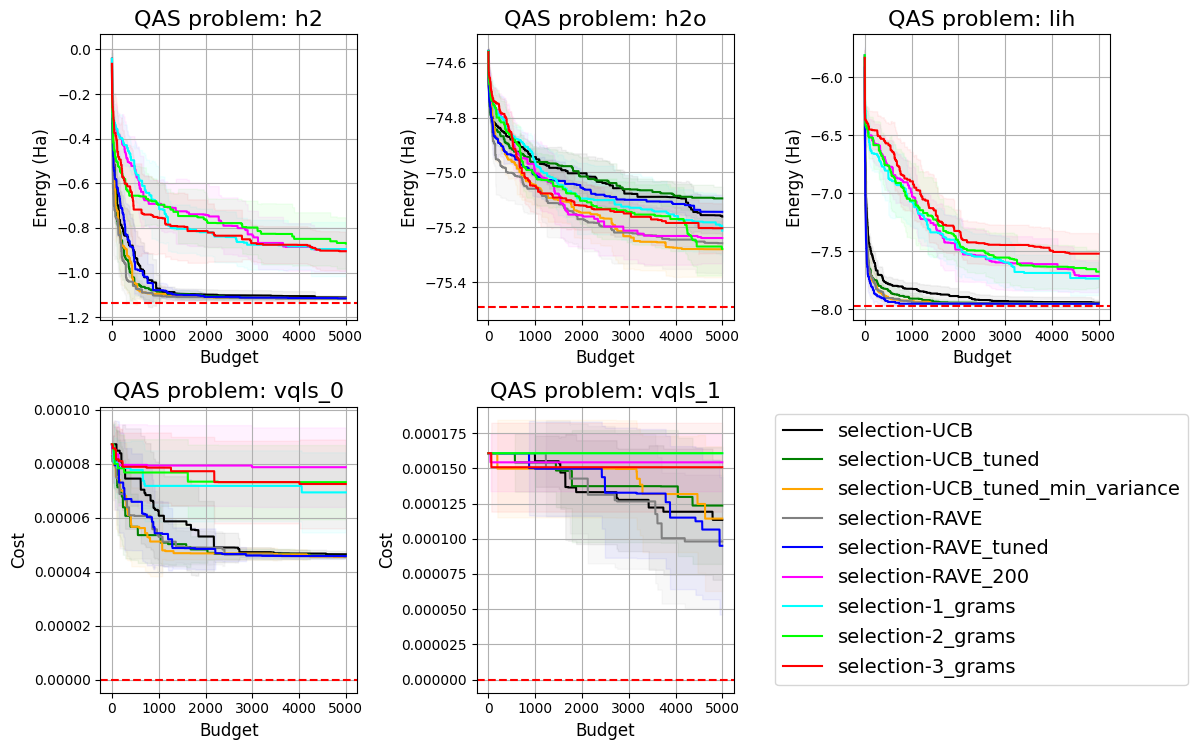

In [8]:
# All
analysing_utils.plot_figure(problems, variants, optimal_value, convergence, color_palette, baseline, reverse_values=True)

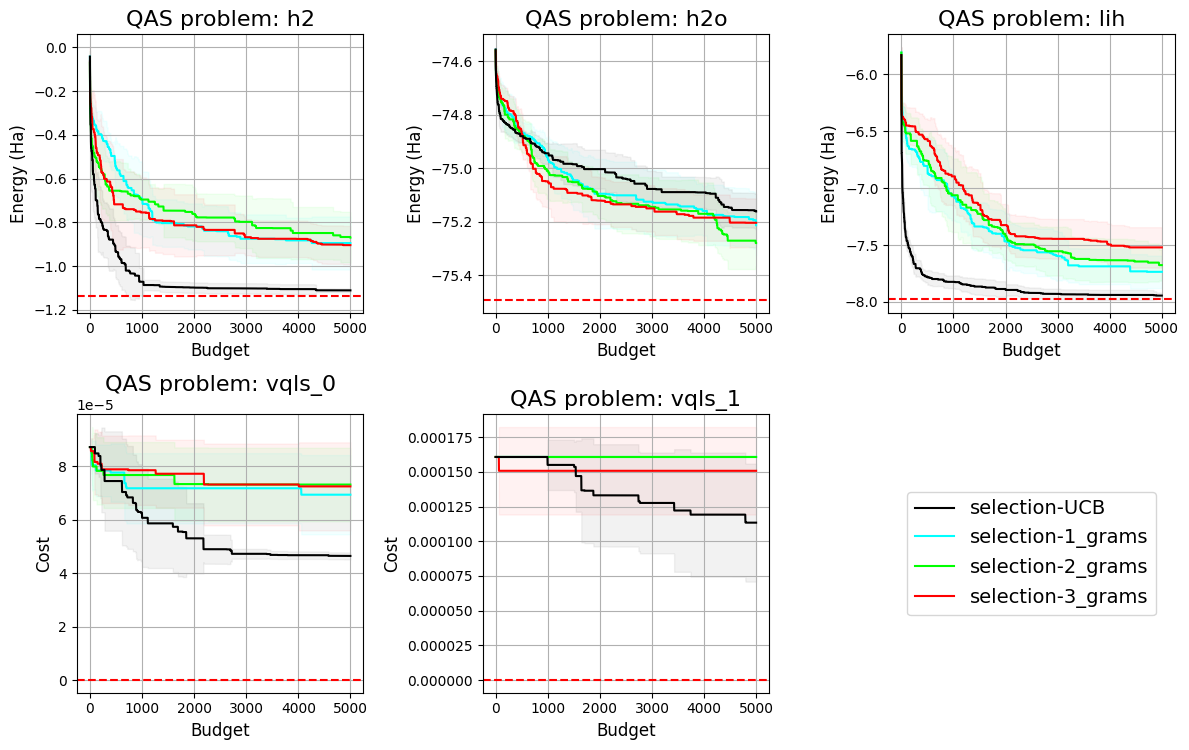

In [9]:
# n-grams, UCB
variants = ['selection-1_grams', 'selection-2_grams', 'selection-3_grams', 'selection-UCB']
convergence_grams = analysing_utils.converge_all(results, problems, variants)
analysing_utils.plot_figure(problems, variants, optimal_value, convergence_grams, color_palette, baseline, reverse_values=True)

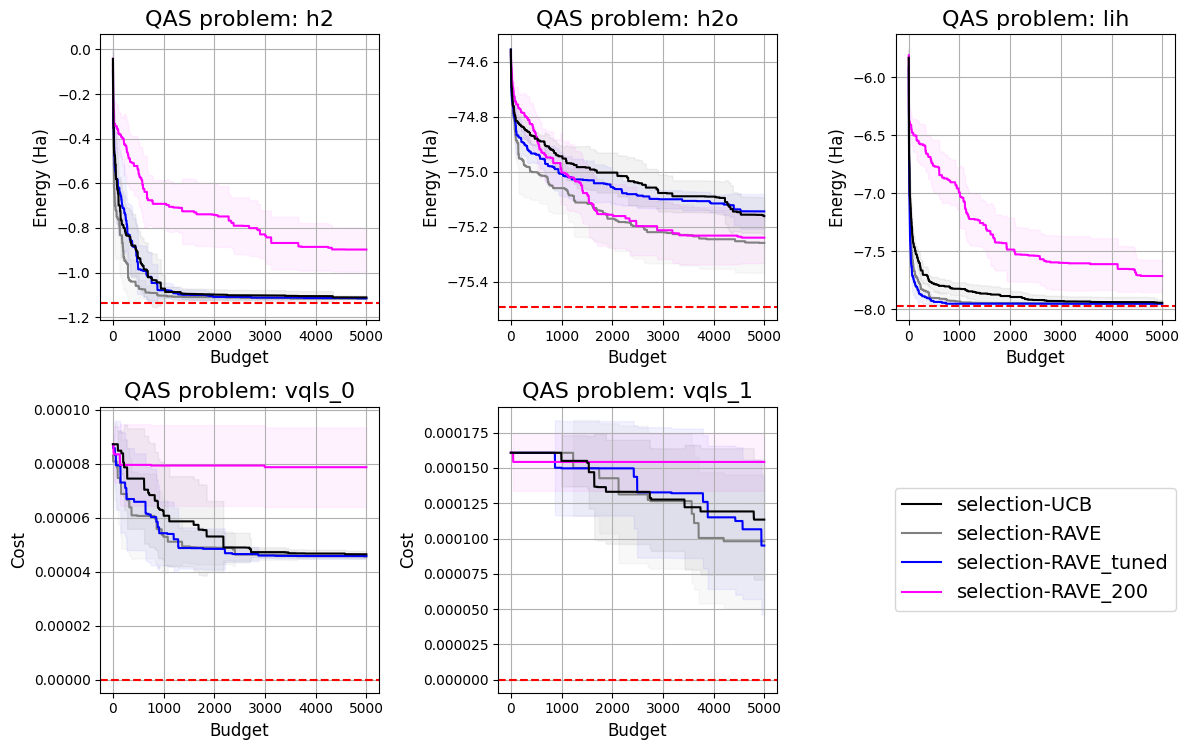

In [10]:
# RAVE, UCB
variants = ['selection-RAVE', 'selection-RAVE_tuned', 'selection-RAVE_200', 'selection-UCB']
convergence_rave = analysing_utils.converge_all(results, problems, variants)
analysing_utils.plot_figure(problems, variants, optimal_value, convergence_rave, color_palette, baseline, reverse_values=True)

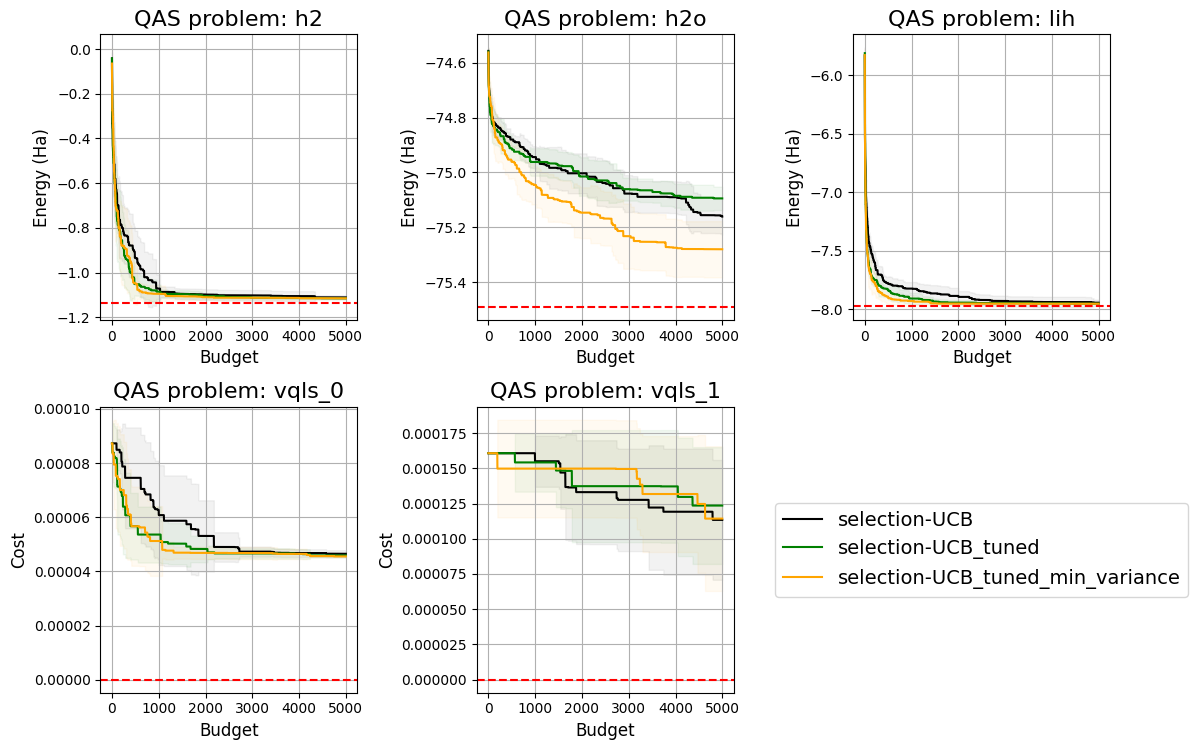

In [11]:
# all UCB
variants = ['selection-UCB', 'selection-UCB_tuned', 'selection-UCB_tuned_min_variance']
convergence_ucb = analysing_utils.converge_all(results, problems, variants)
analysing_utils.plot_figure(problems, variants, optimal_value, convergence_ucb, color_palette, baseline, reverse_values=True)

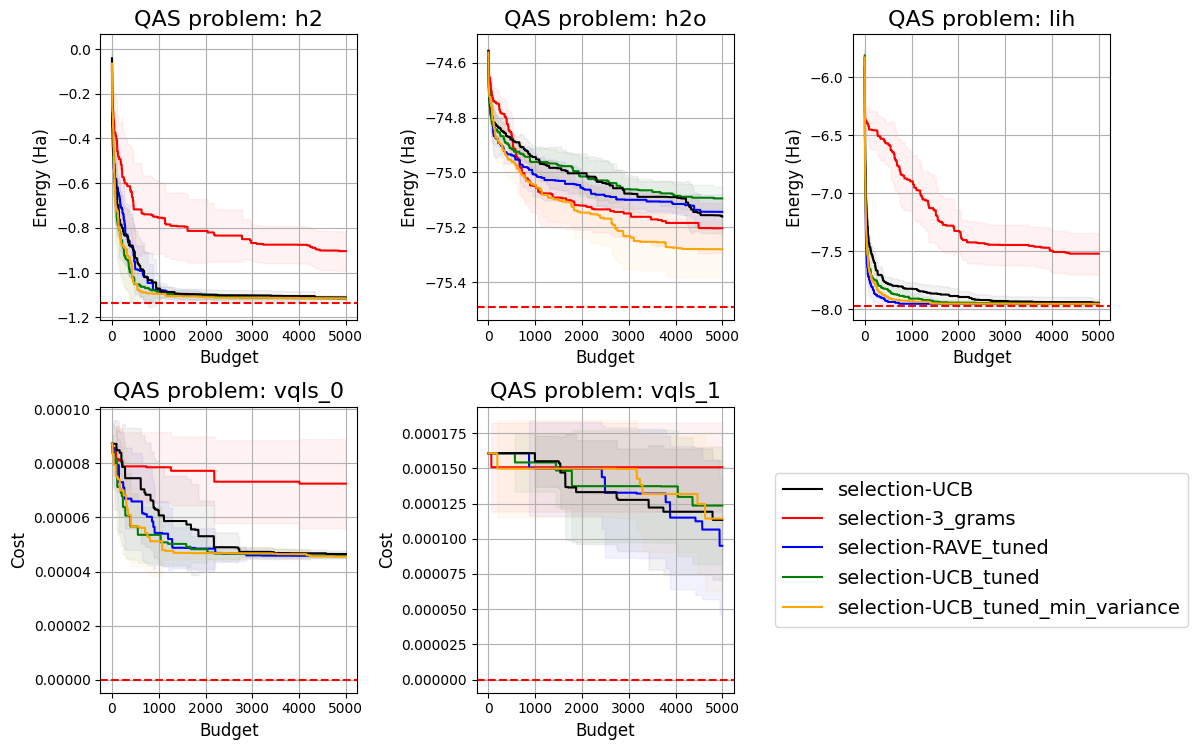

In [12]:
# best of each (3-grams, RAVE-tuned, UCB-tuned, UCB, UCB-tuned-min)
variants = ['selection-3_grams', 'selection-RAVE_tuned', 'selection-UCB_tuned', 'selection-UCB', 'selection-UCB_tuned_min_variance']
convergence_best = analysing_utils.converge_all(results, problems, variants)
analysing_utils.plot_figure(problems, variants, optimal_value, convergence_best, color_palette, baseline, reverse_values=True)

#### Statistical Analysis

In [13]:
# get std, Friedman, and Nemenyi test\
analysing_utils.statistically_analyze(results, baseline, 
                      save_csv="stats_results.csv", 
                      save_tex="stats_results.tex")


📋 Mean, StdDev and Max per Problem and Variant:
                                               mean       std    maximum
problem variant                                                         
h2      selection-1_grams                  0.894720  0.121243   1.096731
        selection-2_grams                  0.869834  0.114554   1.029909
        selection-3_grams                  0.904232  0.087840   1.040369
        selection-RAVE                     1.116614  0.001449   1.117335
        selection-RAVE_200                 0.896651  0.098941   1.057009
        selection-RAVE_tuned               1.115152  0.002155   1.117333
        selection-UCB                      1.111196  0.009009   1.117339
        selection-UCB_tuned                1.115157  0.002858   1.117349
        selection-UCB_tuned_min_variance   1.115285  0.004630   1.117327
h2o     selection-1_grams                 75.212442  0.113373  75.400187
        selection-2_grams                 75.279217  0.087016  75.420094
  

In [14]:
# Plot cd diagram
analysing_utils.summarize_ranks(convergence, baseline='selection-UCB', save_path="rank_summary")

📋 Rank Summary Table (Lower Rank = Better Performance):
                                  QC Average Rank  LA Average Rank  \
variant                                                              
selection-UCB_tuned_min_variance             1.33              2.5   
selection-RAVE                               2.33              2.0   
selection-RAVE_tuned                         4.67              2.0   
selection-UCB                                5.67              4.0   
selection-UCB_tuned                          5.33              4.5   
selection-1_grams                            6.33              7.5   
selection-3_grams                            7.00              6.5   
selection-RAVE_200                           6.00              8.0   
selection-2_grams                            6.33              8.0   

                                  Overall Average Rank  
variant                                                 
selection-UCB_tuned_min_variance                   1.8  
se

,QC Average Rank,LA Average Rank,Overall Average Rank
variant,,,
selection-UCB_tuned_min_variance,1.33,2.5,1.8
selection-RAVE,2.33,2.0,2.2
selection-RAVE_tuned,4.67,2.0,3.6
selection-UCB,5.67,4.0,5.0
selection-UCB_tuned,5.33,4.5,5.0
selection-1_grams,6.33,7.5,6.8
selection-3_grams,7.00,6.5,6.8
selection-RAVE_200,6.00,8.0,6.8
selection-2_grams,6.33,8.0,7.0


#### Boxplot

In [18]:
import analysing_utils
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import lines as mlines
import numpy as np

In [19]:
problems = ['h2', 'h2o', 'lih', 'vqls_0', 'vqls_1']
vql_problems = ['vqls_0', 'vqls_1']
chemistry_problems = ['h2', 'h2o', 'lih']
variants = [ 'selection-UCB', 'selection-UCB_tuned', 'selection-UCB_tuned_min_variance', 'selection-RAVE', 'selection-RAVE_tuned', 'selection-RAVE_200', 'selection-1_grams', 'selection-2_grams', 'selection-3_grams']
optimal_value = {'h2': 1.1373060483, 'h2o': 76.3147, 'lih': 8.070, 'vqls_0': 1, 'vqls_1': 1}

In [20]:
split_variants = []
for variant in variants:
    split_variants = split_variants + variant.split('_')
unique_vars = list(set(split_variants))
unique_vars

table_df = pd.DataFrame(columns=unique_vars)
table_df.head()

for variant in variants:
    variant.split('_')
    for col in unique_vars:
        table_df.at[variant, col] = 1 if col in variant.split('_') else 0

In [21]:
results = analysing_utils.load_mcts_results()

In [22]:
circuit_results = analysing_utils.load_circuit_results()
print(circuit_results)

{'h2': {'selection-test': [], 'selection-1_grams': [1.1173489798899658, 1.1173482165007818, 1.1173490094567955, 1.1173490258127412, 1.117347707774642, 1.1173490085864295, 1.1173490309244376, 1.1173490337625638, 1.1173485672848091, 1.117348835917184], 'selection-RAVE_200': [1.1173490275751732, 1.1173490275823896, 1.1173490222988665, 1.1173489207148406, 1.1173486314269605, 1.1173482555233605, 1.1173490277702594, 1.1173490271842372, 1.1173489540547392, 1.1173490238587502], 'selection-3_grams': [1.1173490151560168, 1.1173490201791658, 1.117349032240811, 1.1173484285005224, 1.1173490153647985, 1.1173490225220075, 1.136189361484171, 1.136189070116269, 1.1173489978033633, 1.1173483080819815], 'selection-2_grams': [1.1361894436375144, 1.117349004141174, 1.1173489259545268, 1.1173490240768291, 1.1173489988848928, 1.1173490150938792, 1.117348370875157, 1.1173489040704114, 1.1173488495473975, 1.1173488205037774], 'selection-UCB_tuned': [1.1173488915862362, 1.1173489980686857, 1.117349012913656, 1

In [23]:
problem_stats = {}
for problem in problems:
    problem_results = []
    for variant in variants:
        problem_results.append(circuit_results[problem][variant])
    print('finished')
    print(problem_results)
    problem_stats[problem] =  analysing_utils.standardize_problem_stats(problem_results)
    print(problem_stats[problem])
print(circuit_results)
problem_stats
# IDK what this does
# analysing_utils.standardize_from_stats(problem_stats["h2"], circuit_results["h2"]["gates"][0])

finished
[[1.1173490348625832, 1.1173490223517966, 1.1173490309533114, 1.1173488377439769, 1.1173488681824613, 1.1173489931594596, 1.117349017137481, 1.1173488649476666, 1.1173490341015917, 1.1173466368874052], [1.1173488915862362, 1.1173489980686857, 1.117349012913656, 1.117348994276337, 1.1173490278668794, 1.1173490248996734, 1.117349023780051, 1.1173490201723189, 1.1173490236735997, 1.1173490338138967], [1.117349026906185, 1.1173487356758791, 1.117348989889267, 1.1173490198745697, 1.117349018054846, 1.1173489816470537, 1.1173443103177576, 1.1173487832887103, 1.1173446478275677, 1.1173489916846284], [1.1173486196851692, 1.117348502299934, 1.117348986299755, 1.1173490205451049, 1.1173490246441693, 1.1173489368339158, 1.1173489946174686, 1.1173490219909323, 1.1173488307768522, 1.1173490232616192], [1.117348979117932, 1.1173490069232457, 1.117349000229268, 1.1173489560214755, 1.1173489604574316, 1.117349034571091, 1.117349011970593, 1.117348991901457, 1.117349034719132, 1.11734903363511

{'h2': {'mean': 1.1179767981020197,
  'std': 0.003381975244357155,
  'min': 1.1173443103177576,
  'max': 1.1361894436375144},
 'h2o': {'mean': 75.27865635277888,
  'std': 0.11956370525284493,
  'min': 74.99740689374494,
  'max': 75.42175241419237},
 'lih': {'mean': 7.912480222618381,
  'std': 0.0746247803322889,
  'min': 7.62959185125713,
  'max': 7.9526500454457505},
 'vqls_0': {'mean': 0.7938343846250017,
  'std': 0.23485109890717273,
  'min': 0.02638175299529771,
  'max': 0.9999999302347822},
 'vqls_1': {'mean': 0.9121737101808675,
  'std': 0.06348341819678513,
  'min': 0.6723134589951612,
  'max': 0.9999999975289677}}

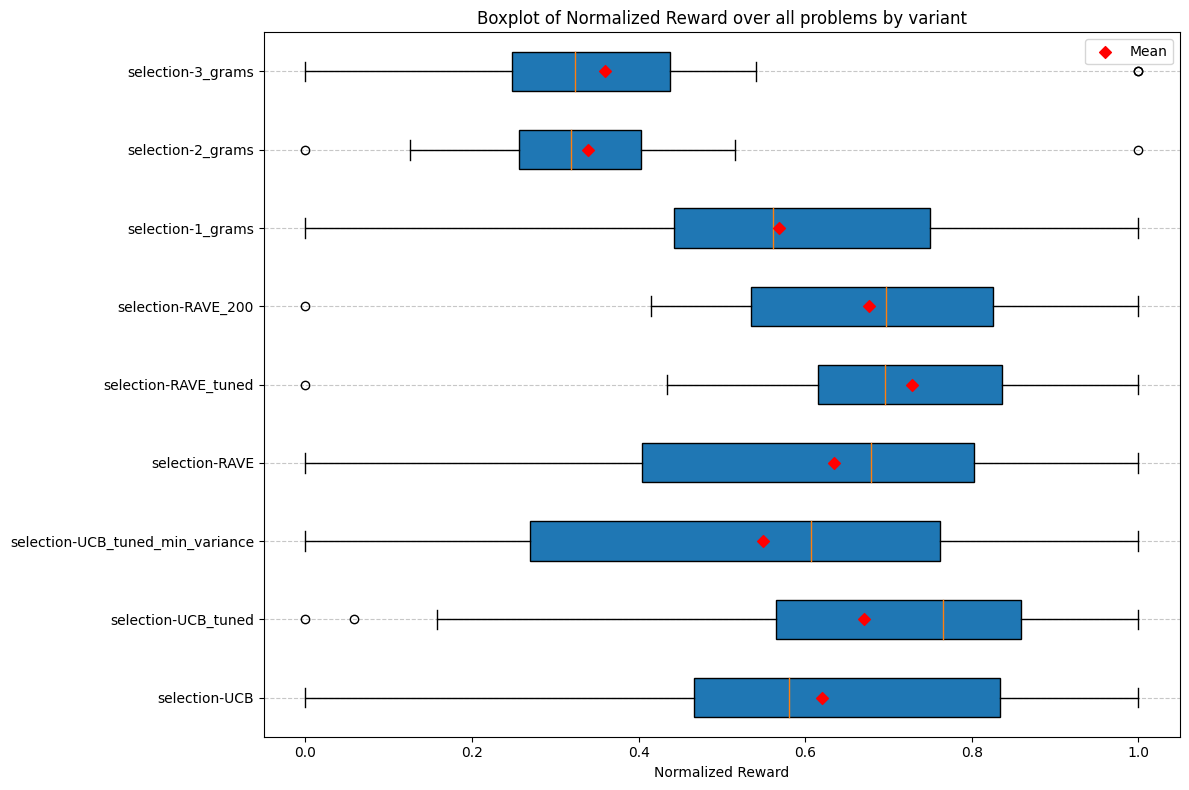

In [24]:
# variant_results = {}
# for variant in variants:
#     standardized_results = []
#     for problem in problems:
#         for run in circuit_results[problem][variant]:
#             result = analysing_utils.standardize_from_stats(problem_stats[problem], run)
#             standardized_results.append(result)
#     variant_results[variant] = standardized_results
    
# plt.figure(figsize=(12, 8))

# # Create the boxplot
# bp = plt.boxplot(variant_results.values(), labels=variant_results.keys(), vert=False, patch_artist=True)

# # Calculate the means
# means = [np.mean(values) for values in variant_results.values()]
# positions = np.arange(1, len(means) + 1)  # Y positions for horizontal boxplot

# # Plot the means as red diamonds
# plt.scatter(means, positions, color='red', marker='D', label='Mean', zorder=3)

# # Add labels and title
# plt.xlabel('Standardized Reward')
# plt.title('Boxplot of Standardized Reward over all problems by variant')
# plt.grid(axis='y', linestyle='--', alpha=0.7)  # Horizontal grid lines
# plt.legend()
# plt.tight_layout()
# plt.show()



# Assuming `variants`, `problems`, `circuit_results`, and `problem_stats` are defined earlier in the code
variant_results = {}

# Standardize and normalize the results
for variant in variants:
    standardized_results = []
    for problem in problems:
        for run in circuit_results[problem][variant]:
            # Standardize the result using your custom standardization function
            result = analysing_utils.standardize_from_stats(problem_stats[problem], run)
            standardized_results.append(result)
    
    # Normalize the standardized results to the [0, 1] range
    min_val = np.min(standardized_results)
    max_val = np.max(standardized_results)
    normalized_results = (standardized_results - min_val) / (max_val - min_val)
    
    # Store the normalized results
    variant_results[variant] = normalized_results

# Create the boxplot for normalized results
plt.figure(figsize=(12, 8))

# Create the boxplot
bp = plt.boxplot(variant_results.values(), labels=variant_results.keys(), vert=False, patch_artist=True)

# Calculate the means of the normalized results
means = [np.mean(values) for values in variant_results.values()]
positions = np.arange(1, len(means) + 1)  # Y positions for horizontal boxplot

# Plot the means as red diamonds
plt.scatter(means, positions, color='red', marker='D', label='Mean', zorder=3)

# Add labels and title
plt.xlabel('Normalized Reward')
plt.title('Boxplot of Normalized Reward over all problems by variant')
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Horizontal grid lines
plt.legend()
plt.tight_layout()
plt.show()



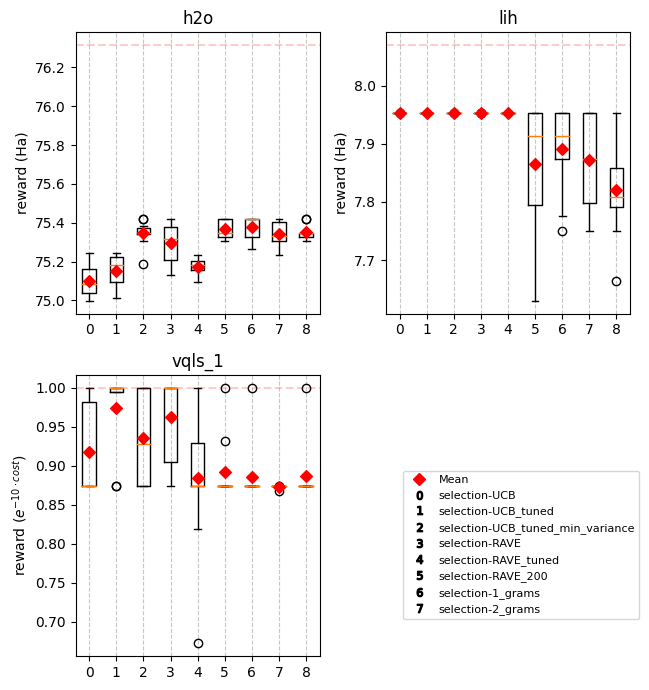

In [28]:
curate = variants
circuit_results_curated = {
    problem: {key: circuit_results[problem][key] for key in curate if key in circuit_results[problem]}
    for problem in problems
}

problems_curated = problems.copy()
# Removing 'vqls_0' and 'h2'
problems_curated.remove('vqls_0')
problems_curated.remove('h2')

# Create subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(6.5, 7))
axes = axes.flatten()

# Plotting loop
for i, problem in enumerate(problems_curated):
    ax = axes[i]
    data = list(circuit_results_curated[problem].values())

    # Create boxplot
    bp = ax.boxplot(data, labels=range(len(data)))

    # Calculate means and plot them as red diamonds
    means = [np.mean(values) for values in data]
    positions = np.arange(1, len(means) + 1)  # Match box positions
    ax.scatter(positions, means, color='red', marker='D', label='Mean' if i == 0 else "", zorder=3)

    # Plot the optimal value line
    ax.axhline(y=optimal_value[problem], color='red', linestyle='--', alpha=0.2)

    ax.set_title(f"{problem}")
    if problem in ['h2o', 'lih']:
        ax.set_ylabel("reward (Ha)")
    else:
        ax.set_ylabel(r"reward ($e^{-10 \cdot cost}$)")

    ax.grid(axis='x', linestyle='--', alpha=0.7)  # Add horizontal grid lines

# Set up the labels for the legend
labels = variants

# Create dummy handles for the boxplot labels
handles = [mlines.Line2D([], [], color='black', marker=f'${i}$', linestyle='None') for i in range(8)]

# Add Mean handle at the front
mean_handle = mlines.Line2D([], [], color='red', marker='D', linestyle='None', label='Mean')

# Create combined legend
fig.legend(
    [mean_handle] + handles,
    ['Mean'] + labels,
    loc='lower right',
    ncol=1,
    bbox_to_anchor=(1, 0.1),
    prop={'size': 8}
)

# Hide the last subplot for layout balance
axes[-1].axis('off')

plt.tight_layout()
plt.show()

['selection-UCB', 'selection-UCB_tuned', 'selection-UCB_tuned_min_variance', 'selection-RAVE', 'selection-RAVE_tuned', 'selection-RAVE_200', 'selection-1_grams', 'selection-2_grams', 'selection-3_grams']
{'selection-test': [], 'selection-1_grams': [1.1173489798899658, 1.1173482165007818, 1.1173490094567955, 1.1173490258127412, 1.117347707774642, 1.1173490085864295, 1.1173490309244376, 1.1173490337625638, 1.1173485672848091, 1.117348835917184], 'selection-RAVE_200': [1.1173490275751732, 1.1173490275823896, 1.1173490222988665, 1.1173489207148406, 1.1173486314269605, 1.1173482555233605, 1.1173490277702594, 1.1173490271842372, 1.1173489540547392, 1.1173490238587502], 'selection-3_grams': [1.1173490151560168, 1.1173490201791658, 1.117349032240811, 1.1173484285005224, 1.1173490153647985, 1.1173490225220075, 1.136189361484171, 1.136189070116269, 1.1173489978033633, 1.1173483080819815], 'selection-2_grams': [1.1361894436375144, 1.117349004141174, 1.1173489259545268, 1.1173490240768291, 1.11734

/opt/homebrew/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/homebrew/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


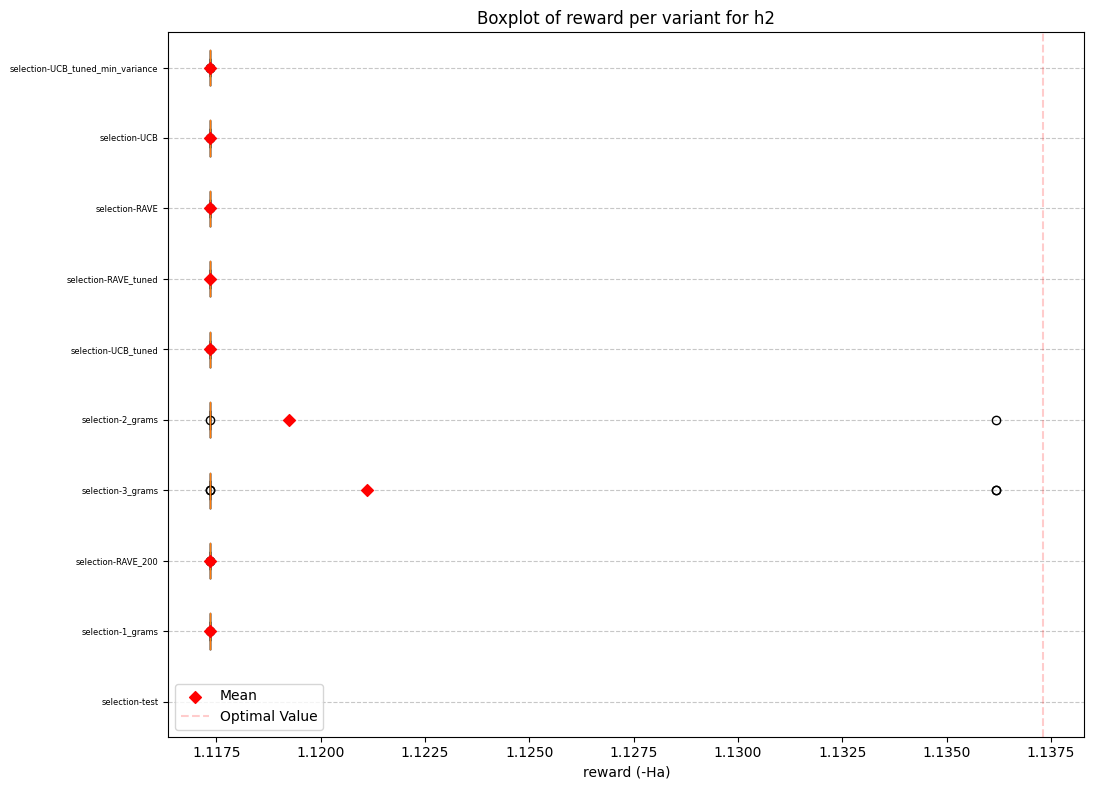

{'selection-1_grams': [75.42175241419237, 75.2659626474904, 75.42175239097207, 75.42175208654741, 75.42174936416683, 75.34580184706645, 75.3171246474042, 75.42175239178911, 75.42175038427479, 75.31712463756078], 'selection-RAVE_200': [75.42175239268138, 75.42175238067036, 75.30498740595121, 75.34567502100327, 75.31712456800774, 75.31712464138943, 75.34580257175462, 75.34580259121077, 75.42175239806474, 75.42175239855115], 'selection-3_grams': [75.42175236802815, 75.31712464111426, 75.34580256481375, 75.34580252877784, 75.34580252617745, 75.30498705777163, 75.34583917010039, 75.34580258778318, 75.31711790595209, 75.42175239709705], 'selection-2_grams': [75.34583916286086, 75.30542106767085, 75.42175238123208, 75.42175055879623, 75.31712464555248, 75.31712457254926, 75.3458025657113, 75.23554894346952, 75.42175235827747, 75.30498736572578], 'selection-UCB_tuned': [75.23547562780601, 75.17610992591096, 75.01283632157123, 75.08072146741037, 75.22974168241726, 75.13167748469999, 75.19917353

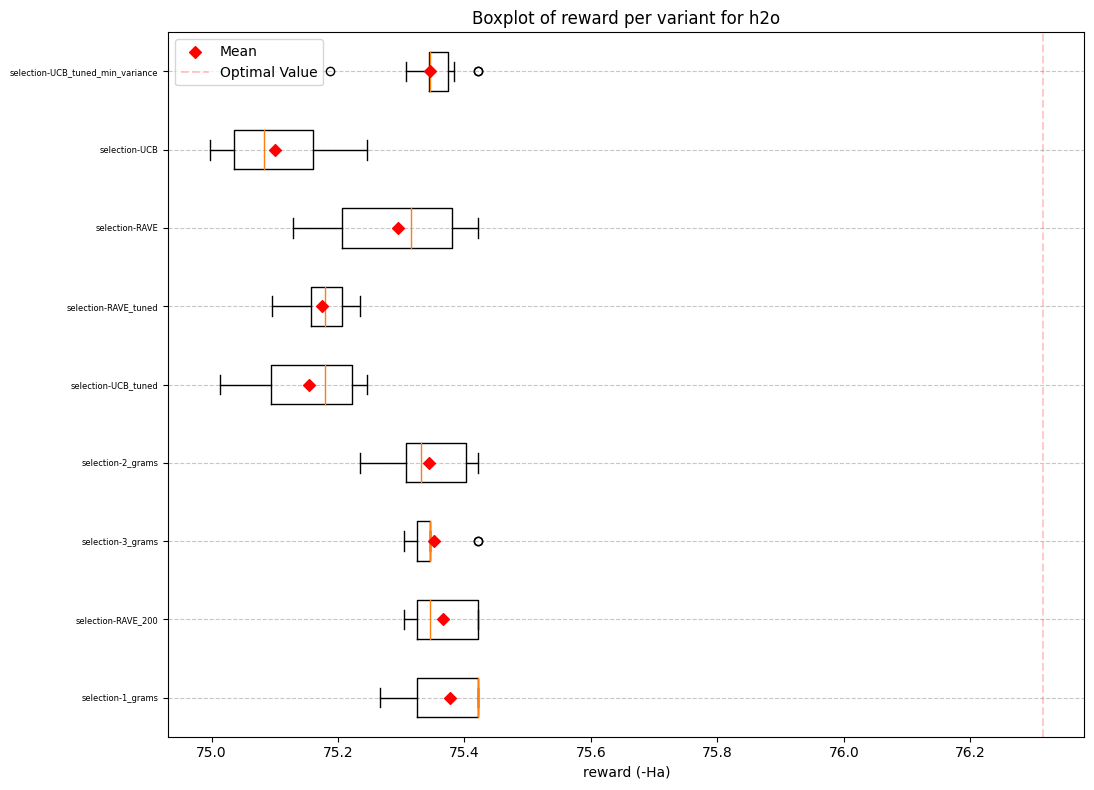

{'selection-1_grams': [7.952650024091032, 7.952650028866278, 7.8738246289171645, 7.952649978648296, 7.952650045445749, 7.9526498777099475, 7.75001089568489, 7.873824596720102, 7.775288186684924, 7.873824573153338], 'selection-RAVE_200': [7.952650032644337, 7.873824624557145, 7.789984130066885, 7.952649999912656, 7.62959185125713, 7.809133683881397, 7.952106487470373, 7.952649757487996, 7.789984134396805, 7.952650031800872], 'selection-3_grams': [7.750011073254815, 7.797170954617874, 7.789984126876712, 7.664286529160244, 7.809133737868168, 7.873824578888262, 7.952649953876922, 7.809133739916477, 7.809133708140327, 7.952650001312], 'selection-2_grams': [7.773195162988165, 7.87382458396678, 7.750011074819169, 7.874503595130353, 7.873754421872372, 7.952650008586144, 7.952650026384266, 7.952650024359757, 7.761603155796253, 7.952649987860385], 'selection-UCB_tuned': [7.952650035311494, 7.952650041837782, 7.952650041829804, 7.9526500454457505, 7.952650045445748, 7.952650040285506, 7.952650045

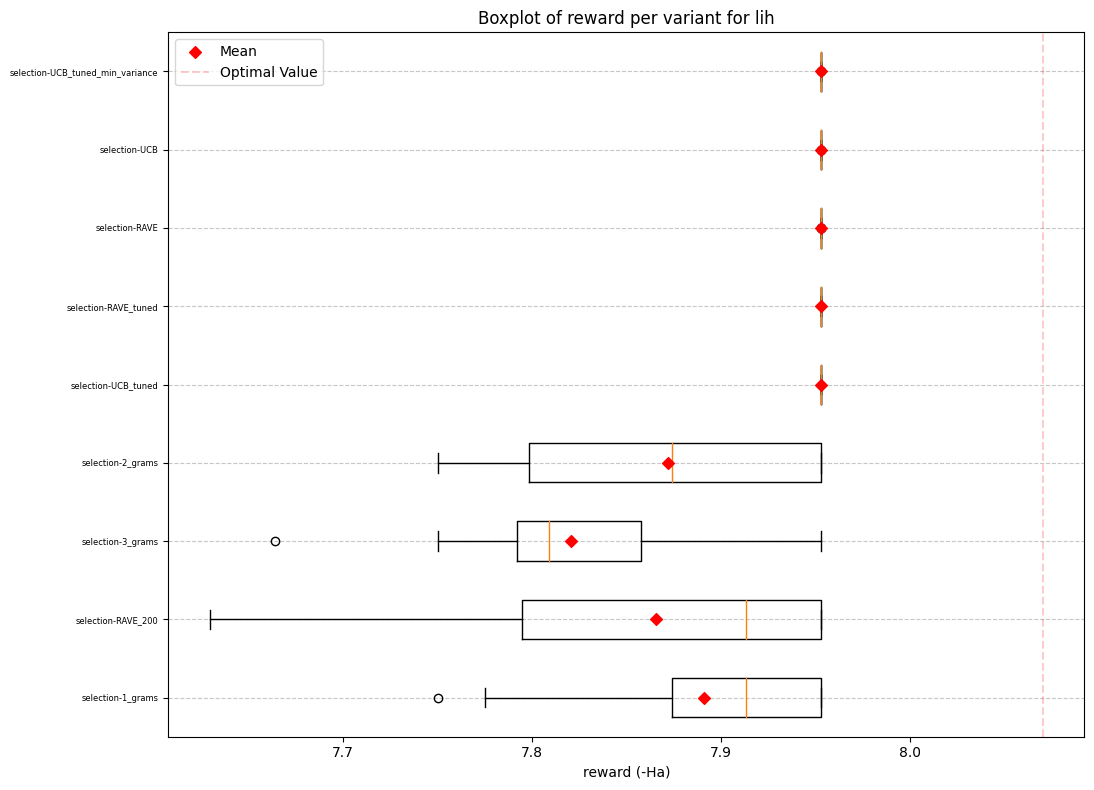

{'selection-1_grams': [0.8497945698702896, 0.520297588622375, 0.520297588622375, 0.573498745105401, 0.520297588622375, 0.520297588622375, 0.6097625486428391, 0.5202975886223685, 0.723945823418835, 0.807417291494515], 'selection-RAVE_200': [0.5202975886223685, 0.520297588622375, 0.520297588622375, 0.520297588622375, 0.5202975886223685, 0.8068575072811444, 0.5202975886223685, 0.520297588622375, 0.5202975886223685, 0.5202975886223685], 'selection-3_grams': [0.5202975886223669, 0.5202975886223685, 0.5801809902908441, 0.5202975886223685, 0.6781519896824199, 0.5202975886223645, 0.9975291388650483, 0.5202975886223685, 0.520297588622375, 0.5202975886223685], 'selection-2_grams': [0.5202975886223669, 0.5202975886223645, 0.02638175299529771, 0.4924292717772588, 0.5202975886223645, 0.4908874774894004, 0.5202975886223645, 0.5202975886223645, 0.5202975886223669, 0.5060999462938514], 'selection-UCB_tuned': [0.7703535150903664, 0.9997057393588616, 0.9997370538819241, 0.9530101142478753, 0.99974294914

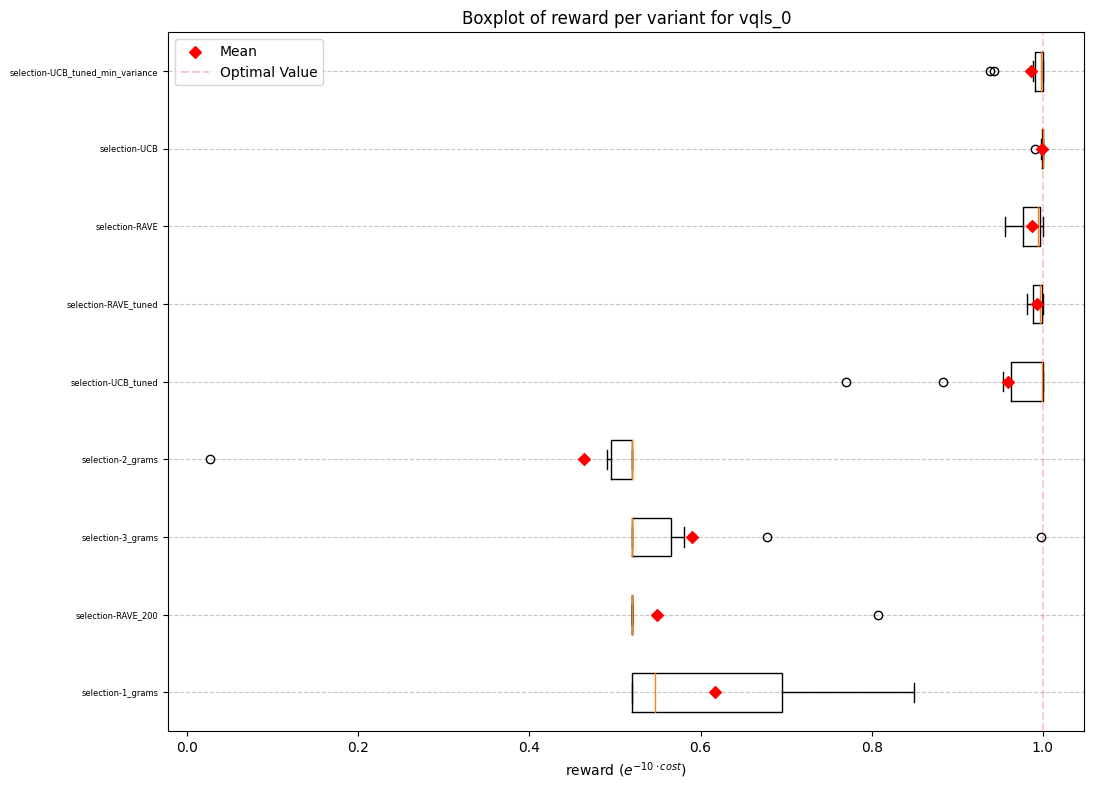

{'selection-1_grams': [0.8735978499475588, 0.8735978499475588, 0.9991741341933765, 0.8735978499475588, 0.8735978499475605, 0.8735978499475588, 0.8735978499475605, 0.8735978499475605, 0.8735978499475605, 0.8735978499475605], 'selection-RAVE_200': [0.8735978499475588, 0.8735978499475588, 0.8735978499475588, 0.8735978499475605, 0.8735978499475605, 0.8735978499475588, 0.9310938489672964, 0.8735978499475588, 0.9999998023223653, 0.8735978499475605], 'selection-3_grams': [0.999999989948053, 0.8735978499475605, 0.8735978499475605, 0.8735978499475588, 0.8735978499475588, 0.8735978499475605, 0.8735978499475588, 0.8735978499475588, 0.8735978499475605, 0.8735978499475588], 'selection-2_grams': [0.8735978499475588, 0.8735215067967614, 0.8735978499475588, 0.8735978499475588, 0.8669980444868189, 0.8735978499475588, 0.8735978499475588, 0.8735978499475588, 0.8735978499475588, 0.8735978499475588], 'selection-UCB_tuned': [0.9999945799565279, 0.9999998372826869, 0.8735978499475605, 0.9970798719678796, 0.9

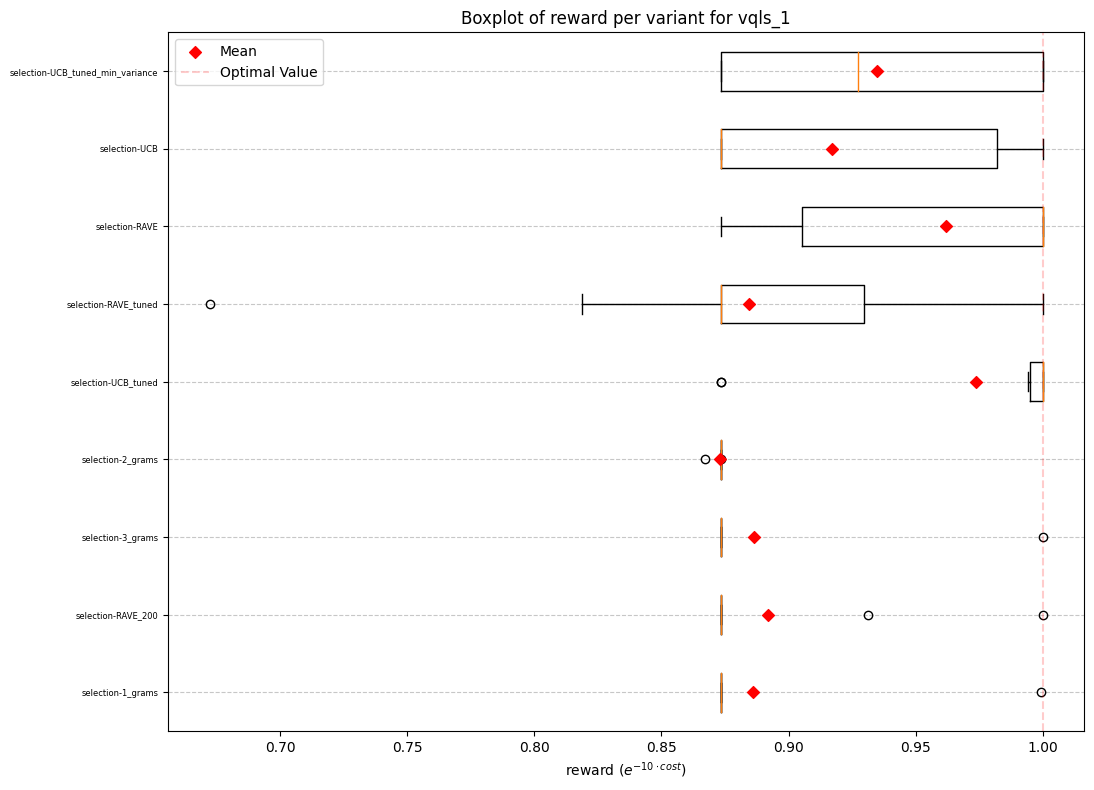

In [29]:
labels = variants
print(labels)

for problem in problems:

    plt.figure(figsize=(12, 8))
    data = list(circuit_results[problem].values())
    keys = list(circuit_results[problem].keys())

    print(circuit_results[problem])

    # Create boxplot
    plt.boxplot(data, labels=keys, vert=False)

    # Plot the mean as red diamonds
    means = [np.mean(values) for values in data]
    positions = np.arange(1, len(means) + 1)  # Match y positions for horizontal plot
    plt.scatter(means, positions, color='red', marker='D', label='Mean', zorder=3)

    # Plot the optimal value as vertical line
    plt.axvline(x=optimal_value[problem], color='red', linestyle='--', label='Optimal Value', alpha=0.2)

    if problem in ['h2', 'h2o', 'lih']:
        plt.xlabel("reward (-Ha)")
    else:
        plt.xlabel(r"reward ($e^{-10 \cdot cost}$)")

    plt.title(f"Boxplot of reward per variant for {problem}")
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add horizontal grid lines
    plt.legend()
    plt.yticks(fontsize=6)
    plt.show()